<a href="https://colab.research.google.com/gist/francischisom/f286a695e77bfdc31637557575556e7b/bilstm_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bi-LSTM + Attention

> A bidirectional LSTM reads each report **left-to-right and right-to-left**; an attention layer then weights the most informative tokens. Those attention weights double as built-in interpretability.


**Needs a GPU runtime** (PyTorch). Dependencies: `bilstm_attention.py`, `eval_utils.py`, the split CSVs.

##  Setup & Important installation/importations

In [ ]:
!pip install -q torch numpy pandas scikit-learn matplotlib

In [ ]:
import sys; sys.path.append('.')
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

import eval_utils as ev
import bilstm_attention as bl
logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
NAVY, RED, GREEN, GRAY = '#00002D', '#C44E52', '#2E8B57', '#4C72B0'
MODEL_KEY = 'bilstm'      # filenames the integrator looks for
MODEL_TITLE = 'Bi-LSTM'

In [ ]:
# Load the  splits from preprocessing
train_df, val_df, test_df, full_df = ev.load_splits(
    'train.csv', 'val.csv', 'test.csv', 'unified_full.csv')

# uids are the join key the ensemble uses to probability
val_df = ev.add_uid(val_df)
test_df = ev.add_uid(test_df)
y_test = test_df[ev.LABEL_COL].values
print('Train', train_df.shape, '| Val', val_df.shape,
      '| Test', test_df.shape)

Train (2156, 8) | Val (470, 9) | Test (451, 9)


##  Train the Bi-LSTM
`train_model` builds the vocabulary from the **training split only**, then
trains with a positive-class-weighted loss and keeps the best checkpoint
by validation F1.

In [ ]:
model, vocab = bl.train_model(train_df, val_df)
test_proba = bl.predict_proba_on_df(model, vocab, test_df)
val_proba = bl.predict_proba_on_df(model, vocab, val_df)

epoch  1 | loss 0.2782 | val_f1 0.939
epoch  2 | loss 0.0973 | val_f1 0.964
epoch  3 | loss 0.0592 | val_f1 0.963
epoch  4 | loss 0.0501 | val_f1 0.965
epoch  5 | loss 0.0377 | val_f1 0.965
epoch  6 | loss 0.0356 | val_f1 0.967
epoch  7 | loss 0.0366 | val_f1 0.956
epoch  8 | loss 0.0320 | val_f1 0.959


##  Evaluate on the test set

In [ ]:
metrics = ev.compute_metrics(y_test, (test_proba >= 0.5).astype(int),
                             test_proba)
print('Test metrics:', {k: round(v, 4) for k, v in metrics.items()})

Test metrics: {'accuracy': 0.9712, 'precision': 0.9708, 'recall': 0.9815, 'f1': 0.9761, 'f1_macro': 0.9699, 'roc_auc': np.float64(0.9899)}


##  Confusion matrix
The **false negative (missed ADE, bottom-left)** is the costly error in pharmacovigilance.

Missed-ADE (FN) rate: 1.8%


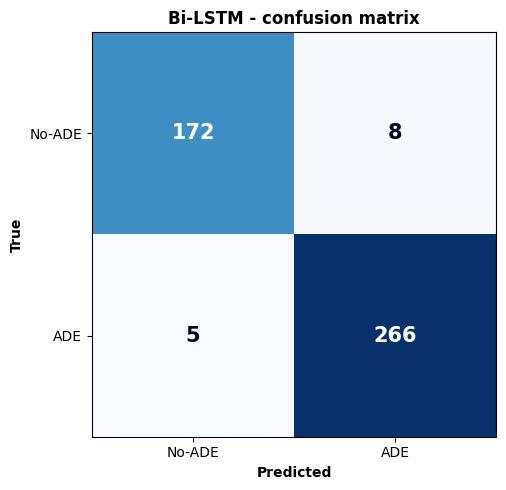

In [ ]:
pred = (test_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['No-ADE', 'ADE'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['No-ADE', 'ADE'])
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('True', fontweight='bold')
ax.set_title(f'{MODEL_TITLE} - confusion matrix', fontweight='bold')
thr = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                fontsize=15, fontweight='bold',
                color='white' if cm[i, j] > thr else NAVY)
tn, fp, fn, tp = cm.ravel()
print(f'Missed-ADE (FN) rate: {fn / (fn + tp) if fn + tp else 0:.1%}')
plt.tight_layout(); plt.savefig(f'{MODEL_KEY}_confusion.png', dpi=200)
plt.show()

##  ROC curve

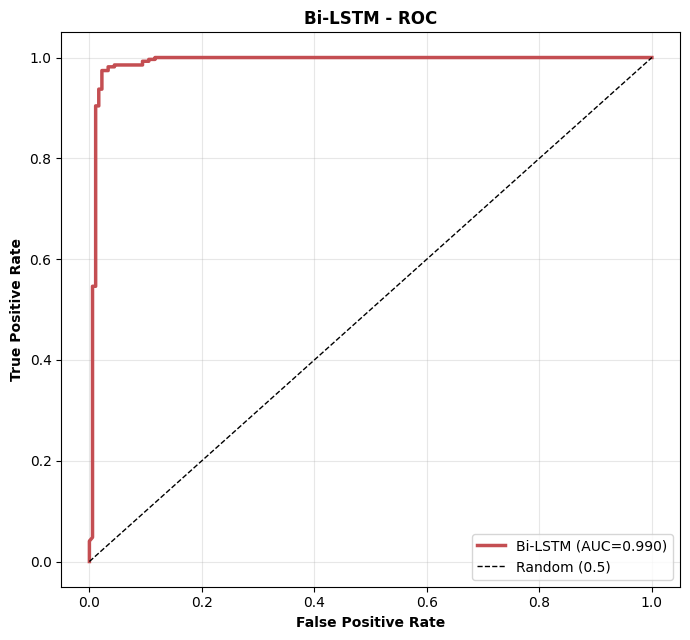

In [ ]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(fpr, tpr, lw=2.5, color=RED,
        label=f'{MODEL_TITLE} (AUC={auc(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.5)')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title(f'{MODEL_TITLE} - ROC', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{MODEL_KEY}_roc.png', dpi=200)
plt.show()

##  Attention interpretability
The attention weights show which tokens drove the decision - the same
mechanism behind our literature paper *Attention Is All You Need*.

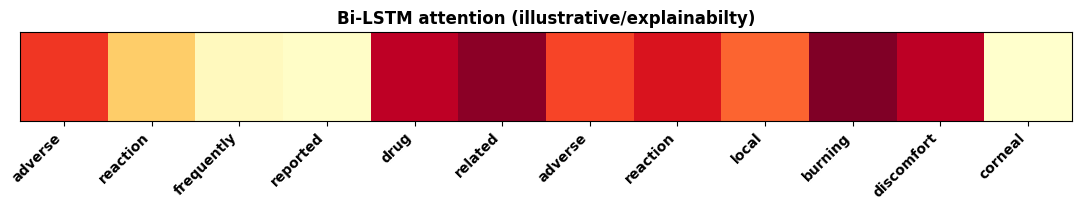

In [ ]:
example = str(test_df[test_df[ev.LABEL_COL] == 1]
              [ev.TEXT_COL].dropna().iloc[0])
try:
    import explainability as xai
    toks, weights = xai.bilstm_attention_for_text(model, vocab, example)
    note = 'real attention'
except Exception:  # noqa: BLE001 - keep the notebook running
    toks = example.split()[:12]
    rng = np.random.default_rng(0)
    weights = rng.random(len(toks)); weights = weights / weights.sum()
    note = 'illustrative/explainabilty'
fig, ax = plt.subplots(figsize=(11, 2.2))
ax.imshow(np.array(weights).reshape(1, -1), cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(toks)))
ax.set_xticklabels(toks, rotation=45, ha='right', fontweight='bold')
ax.set_yticks([])
ax.set_title(f'Bi-LSTM attention ({note})', fontweight='bold')
plt.tight_layout(); plt.savefig('bilstm_attention.png', dpi=200)
plt.show()

##  Cross-domain preview
Train on Formal, test on Informal - the honest generalisation check.

In [ ]:
cross = bl.run_cross_domain(full_df, 'Formal', 'Informal')
gap = pd.DataFrame([ev.degradation_row(MODEL_TITLE, metrics['f1'],
                                       cross['f1'])])
print(gap.to_string(index=False))

  model  f1_standard  f1_cross  degradation_pct
Bi-LSTM       0.9761     0.993             -1.7


##  Export probabilities for ENSEMBLING
we write **uid-keyed** probabilities for val and
test, plus the metrics and gap

In [ ]:
# Probabilities (uid, label, <model>) - val trains the meta-learner,
# test evaluates it
ev.save_probabilities(val_df, val_proba, MODEL_KEY,
                      f'probs_{MODEL_KEY}_val.csv')
ev.save_probabilities(test_df, test_proba, MODEL_KEY,
                      f'probs_{MODEL_KEY}_test.csv')

# Metrics + cross-domain gap (same schema as the other models)
pd.DataFrame([{'model': MODEL_TITLE, **metrics}]).to_csv(
    f'metrics_{MODEL_KEY}.csv', index=False)
gap.to_csv(f'gap_{MODEL_KEY}.csv', index=False)

print('Exported:',
      f'probs_{MODEL_KEY}_val.csv, probs_{MODEL_KEY}_test.csv,',
      f'metrics_{MODEL_KEY}.csv, gap_{MODEL_KEY}.csv')

Saved 470 probabilities -> probs_bilstm_val.csv
Saved 451 probabilities -> probs_bilstm_test.csv
Exported: probs_bilstm_val.csv, probs_bilstm_test.csv, metrics_bilstm.csv, gap_bilstm.csv


In [ ]:
# check; confirm the export is ready for ensemble
_chk = pd.read_csv(f'probs_{MODEL_KEY}_test.csv')
assert {'uid', 'label', MODEL_KEY}.issubset(_chk.columns)
print('verified - columns:', list(_chk.columns),
      '| rows:', len(_chk))

verified - columns: ['uid', 'label', 'bilstm'] | rows: 451
